In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [4]:
df = pd.read_csv("sales_data.csv")
df.head()

,date,sales
0,2023-01-01,200
1,2023-02-01,220
2,2023-03-01,250
3,2023-04-01,270
4,2023-05-01,300


In [5]:
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year

df.head()

,date,sales,month,year
0,2023-01-01,200,1,2023
1,2023-02-01,220,2,2023
2,2023-03-01,250,3,2023
3,2023-04-01,270,4,2023
4,2023-05-01,300,5,2023


In [6]:
X = df[['year', 'month']]
y = df['sales']

In [7]:
model = LinearRegression()
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [8]:
df['predicted_sales'] = model.predict(X)

df

,date,sales,month,year,predicted_sales
0,2023-01-01,200,1,2023,201.783489
1,2023-02-01,220,2,2023,221.004673
2,2023-03-01,250,3,2023,240.225857
3,2023-04-01,270,4,2023,259.447040
4,2023-05-01,300,5,2023,278.668224
5,2023-06-01,280,6,2023,297.889408
6,2023-07-01,310,7,2023,317.110592
7,2023-08-01,330,8,2023,336.331776
8,2023-09-01,350,9,2023,355.552960
9,2023-10-01,370,10,2023,374.774143


In [9]:
mae = mean_absolute_error(y, df['predicted_sales'])
rmse = np.sqrt(mean_squared_error(y, df['predicted_sales']))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 7.994115610933578
RMSE: 9.796960909378674


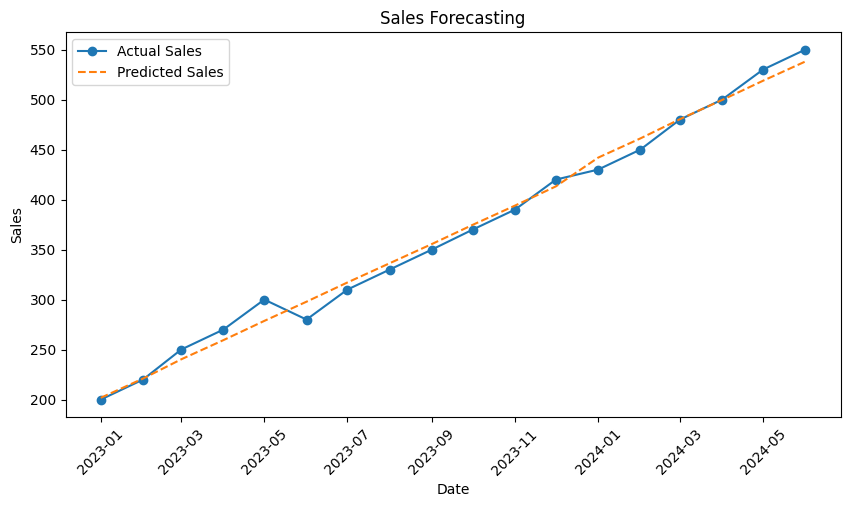

In [10]:
plt.figure(figsize=(10,5))
plt.plot(df['date'], df['sales'], label="Actual Sales", marker='o')
plt.plot(df['date'], df['predicted_sales'], label="Predicted Sales", linestyle='--')
plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Sales Forecasting")
plt.legend()
plt.xticks(rotation=45)
plt.show()

In [11]:
future_dates = pd.date_range(start='2024-07-01', periods=6, freq='MS')
future_df = pd.DataFrame({
    'year': future_dates.year,
    'month': future_dates.month
})

future_predictions = model.predict(future_df)

future_result = pd.DataFrame({
    'date': future_dates,
    'forecasted_sales': future_predictions
})

future_result

,date,forecasted_sales
0,2024-07-01,557.274143
1,2024-08-01,576.495327
2,2024-09-01,595.716511
3,2024-10-01,614.937695
4,2024-11-01,634.158879
5,2024-12-01,653.380062
